In [2]:
import pandas as pd
import numpy as np

In [3]:
ml_data = pd.read_csv('../data/4_ml_data.csv')


In [3]:
"""
How do key operating changes relate to margin deterioration, and do these relationships exhibit
meaningful nonlinear behaviour?
"""

'\nHow do key operating changes relate to margin deterioration, and do these relationships exhibit\nmeaningful nonlinear behaviour?\n'

In [ ]:
# Imports

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GroupKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_squared_error

import shap


In [ ]:

# Features + Target

cat_features = ['store_id', 'product_subcategory']
num_features = ['unit_cost_change_pct', 'list_price_change_pct', 'discount_change_pp', 'base_margin_pct',\
                'base_discount_rate']

x = ml_data[cat_features + num_features]
y = ml_data['margin_delta_pp']


# Train / Test split

train_orders, test_orders = train_test_split(
    ml_data['order_id'].unique(),
    test_size=0.20,
    random_state=42
)

train_mask = ml_data['order_id'].isin(train_orders)
test_mask = ml_data['order_id'].isin(test_orders)

x_train = x.loc[train_mask]
x_test = x.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]


In [ ]:
# Preprocessor and Modeling Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat', 
            OneHotEncoder(handle_unknown='ignore',
                          sparse_output=False
            ), 
            cat_features
        ),
        ('num', 'passthrough', num_features)
    ]
)

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42))
])


In [ ]:
# Baseline Cross Validation


train_groups = ml_data.loc[train_mask, 'order_id']
group_cv = GroupKFold(n_splits=5)


baseline_models = {
    'Linear Regression': lr_pipeline,
    'XGBoost': xgb_pipeline
}

cv_results = []

for model_name, model in baseline_models.items():
    cv_scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=group_cv,
        groups=train_groups,
        scoring='neg_root_mean_squared_error'
    )

    rmse_scores = -cv_scores

    r2_scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=group_cv,
        groups=train_groups,
        scoring='r2'
    )

    cv_results.append({
        'Model': model_name,
        'CV RMSE mean': rmse_scores.mean(),
        'CV R2 mean': r2_scores.mean(),
        'CV RMSE std': rmse_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

print('BASELINE CROSS-VALIDATION')
print(cv_results_df.sort_values('CV RMSE mean').to_string(index=False))

BASELINE CROSS-VALIDATION
            Model  CV RMSE mean  CV R2 mean  CV RMSE std
          XGBoost      0.179006    0.995933     0.001078
Linear Regression      0.294783    0.988971     0.003250


In [ ]:
# XGBoost Tuning

xgb_param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__max_depth': [2, 3, 4, 5, 6],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=30,
    cv=group_cv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(x_train, y_train, groups=train_groups)

print('BEST XGBOOST PARAMETERS')
print(xgb_search.best_params_)

print('\nBEST XGBOOST CV RMSE')
print(-xgb_search.best_score_)


BEST XGBOOST PARAMETERS
{'model__subsample': 1.0, 'model__n_estimators': 500, 'model__max_depth': 6, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}

BEST XGBOOST CV RMSE
0.10354376007369334


In [ ]:
# Final Test Set Evaluation

xgb_pred = xgb_search.best_estimator_.predict(x_test)

final_results = pd.DataFrame([{
    'Model': 'XGBoost',
    'RMSE': np.sqrt(mean_squared_error(y_test, xgb_pred)),
    'R2': r2_score(y_test, xgb_pred)

}])

final_results

,Model,RMSE,R2
0,XGBoost,0.104815,0.998616


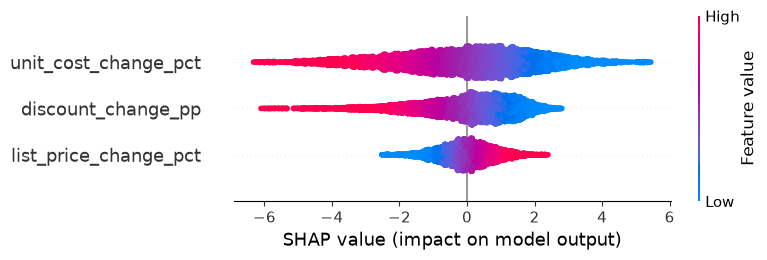

In [ ]:
# SHAP Analysis
# Which features show the strongest relationships with margin change?

# Best tuned XGBoost pipeline
best_xgb = xgb_search.best_estimator_


# Extract fitted preprocessing + model
preprocessor = best_xgb.named_steps['preprocessor']
xgb_model = best_xgb.named_steps['model']


# Extract one-hot encoded feature names safely from the preprocessor
ohe_cols = list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features))
feature_names = ohe_cols + num_features


# Transform the x_test
x_test_transformed = preprocessor.transform(x_test)


# Calculate SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(x_test_transformed)

# Plot SHAP summary

shap.summary_plot(shap_values.values, x_test_transformed, feature_names=feature_names, max_display=3)

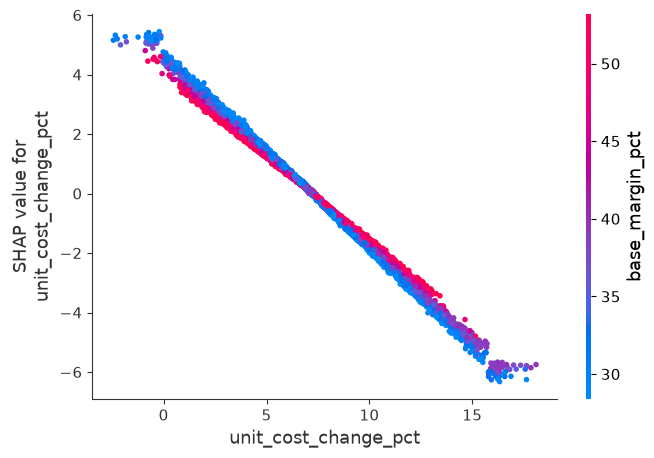

In [ ]:
# Does unit cost change exhibit a nonlinear relationship or threshold effect?

shap.dependence_plot('unit_cost_change_pct', shap_values.values, x_test_transformed, feature_names=feature_names)

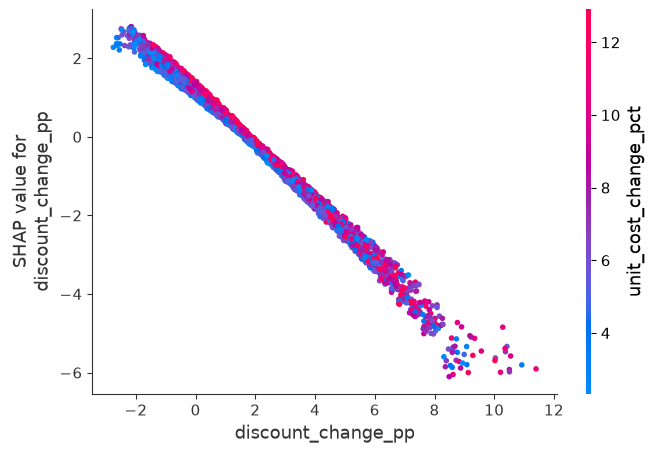

In [ ]:
# Does discount change exhibit a nonlinear relationship or threshold effect?

shap.dependence_plot('discount_change_pp', shap_values.values, x_test_transformed, feature_names=feature_names)

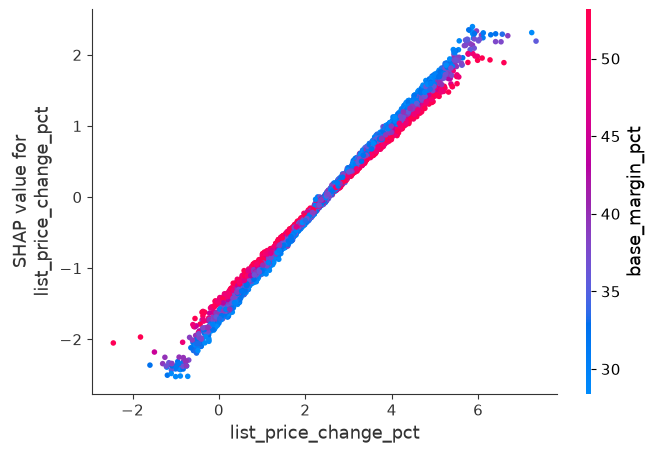

In [ ]:
# Does list price change exhibit a nonlinear relationship or threshold effect?

shap.dependence_plot('list_price_change_pct', shap_values.values, x_test_transformed, feature_names=feature_names)